# Demand-Side Management MPC (DSMPC) HALL AND ERDIN

Copyright &copy; 2024, Alexander Erdin (aerdin@ethz.ch), ETH Zurich

This project is licensed under the MIT License.

## Setup

In [1]:
# Reload scripts when executed
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
import casadi
import cvxpy as cp
import numpy as np
import pandas as pd
from time import sleep
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib import colormaps
from params import DSMPCParams
from systems import LinearSystem
from controllers import EMPC, CEMPC
from IPython.display import clear_output
from utils import adjust_margins

In [117]:
# Fix random seed and print options
np.random.seed(1)
np.set_printoptions(threshold=10000, linewidth=np.inf)

## Approximate Infinite-Horizon Overtaking-Optimal Trajectory

In [4]:
# Define period length and number of periods
T, N = 96, 6

# Load parameters and create system with a long horizon
zeta_max = 40 * np.ones([T,10]); zeta_max[23::24,:] = 1
params_inf = DSMPCParams(N=N*T, T=T, zeta_max=zeta_max, zeta_min=-zeta_max)
sys_inf = LinearSystem(params_inf.sys)

# Initialize controller
ctrl_inf = EMPC(sys_inf, params_inf.ctrl, solver='cvxpy')

# Solve EMPC problem with free initial state
sol_u, sol_x, error_msg, dual_vars_inf, _ = ctrl_inf.solve(t=0)
if error_msg != None:
    warnings.warn(error_msg)

# Save trajectory
x_inf = sol_x.T
u_inf = sol_u.T

### Compare Trajectory

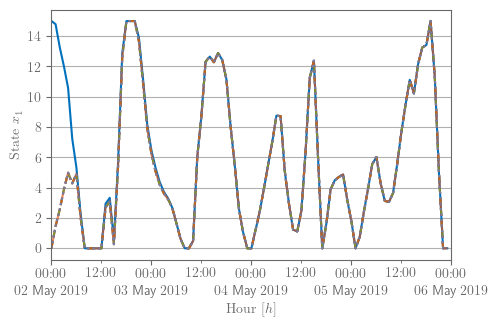

In [5]:
# Set rcParams
export = True
plt.style.use('default') # 'seaborn-v0_8-darkgrid
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.color'] = 'dimgray'
plt.rcParams['ytick.color'] = 'dimgray'
plt.rcParams['axes.edgecolor'] = 'dimgray'
plt.rcParams['axes.labelcolor'] = 'dimgray'
plt.rcParams['lines.linewidth'] = 1.5

# Create dates and norm vector
idx = 1
dates = np.hstack([params_inf.ctrl.start_date + pd.Timedelta(hours = h) for h in range(T+1)])

# Create colormap
colors = lambda i: ["#0072BD", "#A2142F", "#77AC30", "#D95319", "#7E2F8E", "#4DBEEE", "#EDB120"][i % 7]

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')

# Plot trajectory
ls = ['-', '--', '--', '-.', ':', ':']
alpha = [1, 0.9, 0.8, 0.7, 0.6, 0.5]
for i, _ in enumerate(ls):
    ax.plot(dates[:-1], x_inf[i*T:(i+1)*T,idx], ls=ls[i], alpha=alpha[i], color=colors(i))

# Add labels and title
ax.set_xlabel(r'\rmfamily{Hour} $[h]$')
ax.set_ylabel(r'\rmfamily{State} $x_{' + str(idx) + r'}$')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[12]))
ax.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %Y'))
ax.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))
ax.yaxis.set_major_locator(ticker.MultipleLocator(base=2, offset=0))
# ax.tick_params(axis="x", which="minor", pad=ax.xaxis.get_tick_padding())

# Set limits
ax.set_xlim([dates[0], dates[-1]])

# Set grid
ax.yaxis.grid(True)
ax.xaxis.grid(False)

# Export figure
if export:
    fig = adjust_margins(fig, width=4, height=2.5, wspace=1.1)
    fig.savefig(f"figures/figure_trajectory_of_state_{idx}_inf_sol.pdf")

### Compare Multipliers

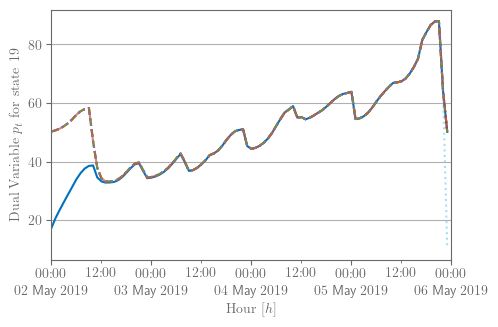

In [6]:
# Set rcParams
export = True
plt.style.use('default') # 'seaborn-v0_8-darkgrid
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.color'] = 'dimgray'
plt.rcParams['ytick.color'] = 'dimgray'
plt.rcParams['axes.edgecolor'] = 'dimgray'
plt.rcParams['axes.labelcolor'] = 'dimgray'
plt.rcParams['lines.linewidth'] = 1.5

# Create dates vector and get state related dual variables
idx = 19
dates = np.hstack([params_inf.ctrl.start_date + pd.Timedelta(hours = h) for h in range(T+1)])
dual_vector_inf = np.hstack(dual_vars_inf[0:ctrl_inf.params.N]).T

# Create colormap
colors = lambda i: ["#0072BD", "#A2142F", "#77AC30", "#D95319", "#7E2F8E", "#4DBEEE", "#EDB120"][i % 7]

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')

# Plot multipliers
ls = ['-', '--', '--', '-.', ':', ':']
alpha = [1, 0.9, 0.8, 0.7, 0.6, 0.5]
for i, _ in enumerate(ls):
    ax.plot(dates[:-1], dual_vector_inf[i*T:(i+1)*T,idx].T, ls=ls[i], alpha=alpha[i], color=colors(i))

# Add labels and title
ax.set_xlabel(r'\rmfamily{Hour} $[h]$')
ax.set_ylabel(r'\rmfamily{Dual Variable $p_{t}$ for state ' + str(idx) + r'}')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[12]))
ax.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %Y'))
ax.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))
ax.yaxis.set_major_locator(ticker.MultipleLocator(base=20, offset=0))
# ax.tick_params(axis="x", which="minor", pad=ax.xaxis.get_tick_padding())

# Set limits
ax.set_xlim([dates[0], dates[-1]])

# Set grid
ax.yaxis.grid(True)
ax.xaxis.grid(False)

# Export figure
if export:
    fig = adjust_margins(fig, width=4, height=2.5, wspace=1.1)
    fig.savefig(f"figures/figure_dual_variable_{idx}_inf_sol.pdf")

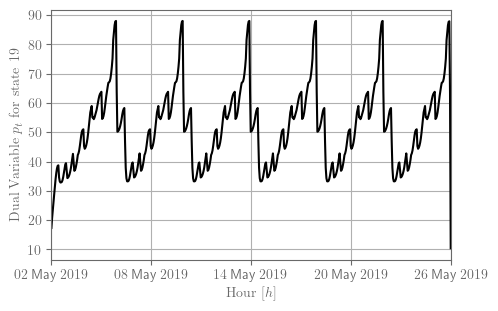

In [7]:
# Set rcParams
export = True
plt.style.use('default') # 'seaborn-v0_8-darkgrid
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.color'] = 'dimgray'
plt.rcParams['ytick.color'] = 'dimgray'
plt.rcParams['axes.edgecolor'] = 'dimgray'
plt.rcParams['axes.labelcolor'] = 'dimgray'
plt.rcParams['lines.linewidth'] = 1.5

# Create dates vector and get state related dual variables
idx = 19
dates = np.hstack([params_inf.ctrl.start_date + pd.Timedelta(hours = h) for h in range(ctrl_inf.params.N+1)])
dual_vector_inf = np.hstack(dual_vars_inf[0:ctrl_inf.params.N]).T

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')

# Plot multipliers
ax.plot(dates[:-1], dual_vector_inf[:,idx].T, color='black')

# Add labels and title
ax.set_xlabel(r'\rmfamily{Hour} $[h]$')
ax.set_ylabel(r'\rmfamily{Dual Variable $p_{t}$ for state ' + str(idx) + r'}')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
ax.xaxis.set_major_locator(mdates.DayLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter(r'%d %b %Y'))
ax.yaxis.set_major_locator(ticker.MultipleLocator(base=10, offset=0))
# ax.tick_params(axis="x", which="minor", pad=ax.xaxis.get_tick_padding())

# Set limits
ax.set_xlim([dates[0], dates[-1]])

# Set grid
ax.yaxis.grid(True)
ax.xaxis.grid(True)

# Export figure
if export:
    fig = adjust_margins(fig, width=4, height=2.5, wspace=1.1)
    fig.savefig(f"figures/figure_dual_variable_{idx}_inf_sol1.pdf")

In [8]:
# Check if dual variables are close
for i in range(N):
    matches = [np.allclose(dual_vector_inf[i*T:(i+1)*T,:], dual_vector_inf[j*T:(j+1)*T,:]) for j in range(6)]
    indices = [i for i, val in enumerate(matches) if val]
    print(f'Period {i} is close to period: {indices}.')

Period 0 is close to period: [0].
Period 1 is close to period: [1, 2, 3, 4].
Period 2 is close to period: [1, 2, 3, 4].
Period 3 is close to period: [1, 2, 3, 4].
Period 4 is close to period: [1, 2, 3, 4].
Period 5 is close to period: [5].


## Simulate System Without Terminal Ingredients

### Solve DSMPC for Varying Initial States

In [9]:
# Load parameters and create system
params = DSMPCParams(T=96, zeta_max=zeta_max, zeta_min=-zeta_max)
sys = LinearSystem(params.sys)

# Initialize controller
ctrl = EMPC(sys, params.ctrl)

# Setup simulation
num_steps = 48
x_0 = [np.tile(np.array([10/4*i, 15/4*i]), 10) for i in range(5)]
num_traj  = len(x_0)

# Allocate state and input trajectories
x = np.full((num_traj, num_steps+1, sys.n), np.nan)
u = np.full((num_traj, num_steps,   sys.m), np.nan)
x_ol = np.full((num_traj, params.ctrl.N+1, sys.n), np.nan)
u_ol = np.full((num_traj, params.ctrl.N,   sys.m), np.nan)

# Simulate closed-loop system
for i, xi_0 in enumerate(tqdm(x_0, desc='Trajectories', leave=False)):
    # Set initial state
    x[i,0,:] = xi_0

    # Simulate closed-loop system
    for t in tqdm(range(num_steps),desc='     MPC', leave=False):
        # Solve the EMPC problem
        sol_u, sol_x, error_msg, _, _ = ctrl.solve(t=t, x_0=x[i,t,:])
        if error_msg != None:
            warnings.warn(error_msg)
            break
        
        # Save open-loop trajectory
        if t == 0:
            x_ol[i,:] = sol_x.T
            u_ol[i,:] = sol_u.T

        # Propagate dynamics and save input
        u[i,t,:]   = sol_u[:,0]
        x[i,t+1,:] = sys.f(sol_x[:,0], sol_u[:,0], t=t).reshape((sys.n,))
        sleep(0.01)

# Clear cell output
clear_output()

### Solve DSMPC for Varying Horizons

In [10]:
# Setup simulation
num_steps = 48
horizon = [6, 9, 12, 18, 24, 36, 48]
num_horizon = len(horizon)

# Allocate state and input trajectories
x2 = np.full((num_horizon, num_steps+1, sys.n), np.nan)
u2 = np.full((num_horizon, num_steps,   sys.m), np.nan)
x2_ol = np.full((num_horizon, num_steps, max(horizon)+1, sys.n), np.nan)
u2_ol = np.full((num_horizon, num_steps, max(horizon),   sys.m), np.nan)

# Simulate closed-loop system
for i, N in enumerate(tqdm(horizon, desc='Horizons', leave=False)):
    # Load parameters and create system
    params2 = DSMPCParams(N=N, T=96, zeta_max=zeta_max, zeta_min=-zeta_max)
    sys2 = LinearSystem(params2.sys)

    # Initialize controller
    ctrl2 = EMPC(sys2, params2.ctrl)

    # Set initial state
    x2[i,0,:] = np.tile(np.array([10, 15]), 10)

    # Simulate closed-loop system
    for t in tqdm(range(num_steps),desc='   MPC', leave=False):
        # Solve the EMPC problem
        sol_u, sol_x, error_msg, _, _ = ctrl2.solve(t=t, x_0=x2[i,t,:])
        if error_msg != None:
            warnings.warn(error_msg)
            break
        
        # Save open-loop trajectory
        x2_ol[i,t,:N+1,:] = sol_x.T
        u2_ol[i,t,:N,:]   = sol_u.T

        # Propagate dynamics and save input
        u2[i,t,:]   = sol_u[:,0]
        x2[i,t+1,:] = sys2.f(sol_x[:,0], sol_u[:,0], t=t).reshape((sys.n,))
        sleep(0.01)

# Clear cell output
clear_output()

### Sophie's Plot

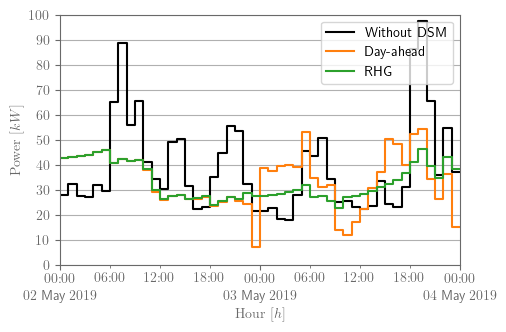

In [11]:
# Set rcParams
export = True
plt.style.use('default') # 'seaborn-v0_8-darkgrid
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.color'] = 'dimgray'
plt.rcParams['ytick.color'] = 'dimgray'
plt.rcParams['axes.edgecolor'] = 'dimgray'
plt.rcParams['axes.labelcolor'] = 'dimgray'
plt.rcParams['lines.linewidth'] = 1.5

# Create time vector
dates = [params.ctrl.start_date + pd.Timedelta(hours = h) for h in range(num_steps+1)]

# Compute passive load without DSM
n_tile = np.ceil(num_steps/sys.T).astype(int)
no_dsm = np.tile(params.ctrl.consumption.sum(axis=1) + params.ctrl.passive_load, n_tile)[:num_steps]
no_dsm = np.hstack([no_dsm, no_dsm[-1]])

# Compute aggregate load
agg_load    = [u[i,:].sum(axis=1) + np.tile(-params.ctrl.solar.sum(axis=1) + params.ctrl.passive_load, n_tile)[:num_steps] for i in range(num_traj)]
agg_load_ol = [np.tile(u_ol[i,:].sum(axis=1), 2) + np.tile(-params.ctrl.solar.sum(axis=1) + params.ctrl.passive_load, n_tile)[:num_steps] for i in range(num_traj)]
agg_load    = [np.hstack([agg_load[t],    agg_load[t][-1]]) for t in range(num_traj)]
agg_load_ol = [np.hstack([agg_load_ol[t], agg_load_ol[t][-1]]) for t in range(num_traj)]

# Create figure
fig, axs = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')

# Plot passive load
axs.plot(dates, no_dsm, label='Without DSM', color='black', linestyle='-', drawstyle='steps-post')

# Plot trajectories
axs.plot(dates, agg_load_ol[0], label='Day-ahead', color='tab:orange', linestyle='-', drawstyle='steps-post')
axs.plot(dates, agg_load[0], label='RHG', color='tab:green', linestyle='-', drawstyle='steps-post')

# Add labels
axs.set_xlabel(r'\rmfamily{Hour} $[h]$')
axs.set_ylabel(r'\rmfamily{Power} $[kW]$')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
axs.xaxis.set_major_locator(mdates.DayLocator(interval=1))
axs.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18]))
axs.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %Y'))
axs.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))
axs.yaxis.set_major_locator(ticker.MultipleLocator(base=10, offset=0))
axs.tick_params(axis="x", which="minor", pad=axs.xaxis.get_tick_padding())

# Set limits
axs.set_xlim([dates[0], dates[-1]])
axs.set_ylim([0, 100])

# Set grid
axs.yaxis.grid(True)
axs.xaxis.grid(False)

# Plot legend
axs.legend(loc='upper right')

# Export figure
if export:
    fig = adjust_margins(fig, width=4, height=2.5, wspace=1.1)
    fig.savefig("figures/figure_hall.pdf")

### Convergence to the Overtaking-Optimal Trajectory

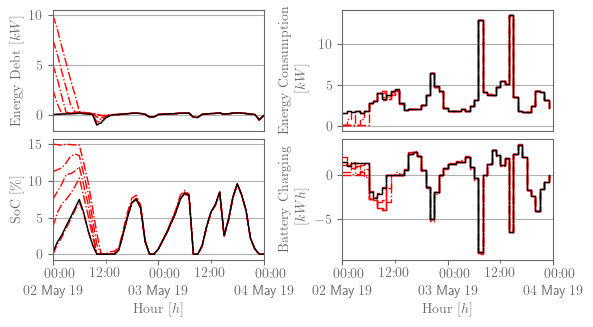

In [12]:
# Set rcParams
export = True
plt.style.use('default') # 'seaborn-v0_8-darkgrid
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.color'] = 'dimgray'
plt.rcParams['ytick.color'] = 'dimgray'
plt.rcParams['axes.edgecolor'] = 'dimgray'
plt.rcParams['axes.labelcolor'] = 'dimgray'
plt.rcParams['lines.linewidth'] = 1

# Create time vector
agent = 9
dates = [params.ctrl.start_date + pd.Timedelta(hours = h) for h in range(num_steps+1)]

# Create figure
fig, axs = plt.subplots(2, 2, figsize=(12, 4), layout='constrained')

# Plot trajectories without terminal constraints
for i in range(num_traj):
    axs[0][0].plot(dates, x[i,:,agent*2], color='red', linestyle='-.')
    axs[1][0].plot(dates, x[i,:,agent*2+1], color='red', linestyle='-.')
    axs[0][1].plot(dates[:-1], u[i,:,agent*2], color='red', linestyle='-.', drawstyle='steps-post')
    axs[1][1].plot(dates[:-1], u[i,:,agent*2+1], color='red', linestyle='-.', drawstyle='steps-post')

# Plot approximate overtaking-optimal trajectories
for i in [2]:
    axs[0][0].plot(dates, x_inf[i*T:i*T+num_steps+1,agent*2], color='black', linestyle='-')
    axs[1][0].plot(dates, x_inf[i*T:i*T+num_steps+1,agent*2+1], color='black', linestyle='-')
    axs[0][1].plot(dates[:-1], u_inf[i*T:i*T+num_steps,agent*2], color='black', linestyle='-', drawstyle='steps-post')
    axs[1][1].plot(dates[:-1], u_inf[i*T:i*T+num_steps,agent*2+1], color='black', linestyle='-', drawstyle='steps-post')

# Add labels
axs[0][0].xaxis.set_visible(False)
axs[0][1].xaxis.set_visible(False)
axs[0][0].set_ylabel(r'\rmfamily{Energy Debt} $[kW]$')
axs[1][0].set_ylabel(r'\rmfamily{SoC} $[\%]$')
axs[0][1].set_ylabel(r'\rmfamily{Energy Consumption}\par$\quad\qquad[kW]$')
axs[1][1].set_ylabel(r'\rmfamily{Battery Charging}\par$\quad\quad[kWh]$')
axs[1][0].set_xlabel(r'\rmfamily{Hour} $[h]$')
axs[1][1].set_xlabel(r'\rmfamily{Hour} $[h]$')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
for ax in axs[1]:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[12])) # [6, 12, 18]
    ax.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %y'))
    ax.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))

for i, ax in enumerate(axs.flatten()):
    # Set axis limits
    ax.set_xlim([dates[0], dates[-1]])

    # Set grid
    ax.yaxis.grid(True)
    ax.xaxis.grid(False)

# Align labels
fig.align_labels()

# Export figure
if export:
    fig = adjust_margins(fig, width=5, height=2.5, wspace=1.2)
    fig.savefig(f"figures/figure_asymptotic_convergence_agent_{agent+1}.pdf")

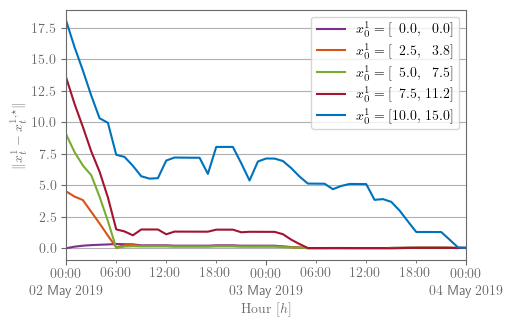

In [13]:
# Set rcParams
export = True
plt.style.use('default') # 'seaborn-v0_8-darkgrid
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.color'] = 'dimgray'
plt.rcParams['ytick.color'] = 'dimgray'
plt.rcParams['axes.edgecolor'] = 'dimgray'
plt.rcParams['axes.labelcolor'] = 'dimgray'
plt.rcParams['lines.linewidth'] = 1.5

# Create time vector
dates = [params.ctrl.start_date + pd.Timedelta(hours = h) for h in range(num_steps+1)]

# Compute L2-norm
diff_x = np.full((num_traj, num_steps+1, params.M), np.nan)
for i in range(num_traj):
    for agent in range(params.M):
        diff_x[i,:,agent] = np.linalg.norm(x[i,:,2*agent:2*(agent+1)] - x_inf[2*T:2*T+num_steps+1,2*agent:2*(agent+1)], axis=1)

# Create colormap
colors = lambda i: ["#0072BD", "#A2142F", "#77AC30", "#D95319", "#7E2F8E", "#4DBEEE", "#EDB120"][i % 7]

# Create figure
agent = 0
fig, axs = plt.subplots(1, 1, figsize=(12, 4), layout='constrained')

# Plot trajectories without terminal constraints
for i in range(num_traj):
    label_name = np.array2string(x_0[i][0:2], separator=',\,', formatter={'float_kind':lambda x: f"{x:4.1f}".replace(' ', r'\phantom{0}')})
    axs.plot(dates, diff_x[i,:,agent], color=colors(num_traj-i-1), linestyle='-', label=f'$x_0^{agent+1} = {label_name}$')

# Add labels
axs.set_ylabel(r'$\|x_t^' + str(agent+1) +' - x_t^{' + str(agent+1) +',\star}\|$')
axs.set_xlabel(r'\rmfamily{Hour} $[h]$')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
axs.xaxis.set_major_locator(mdates.DayLocator(interval=1))
axs.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6,12,18]))
axs.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %Y'))
axs.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))

# Set axis limits
axs.set_xlim([dates[0], dates[-1]])

# Set grid
axs.yaxis.grid(True)
axs.xaxis.grid(False)
# axs.set_yscale('log')

# Align labels
fig.align_labels()

# Plot legend
axs.legend(loc='best')

# Export figure
if export:
    fig = adjust_margins(fig, width=4, height=2.5, wspace=1.1)
    fig.savefig(f"figures/figure_asymptotic_convergence_L2norm_agent_{agent+1}.pdf")

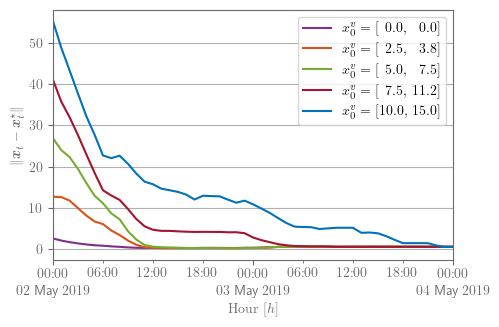

In [14]:
# Set rcParams
export = True
plt.style.use('default') # 'seaborn-v0_8-darkgrid
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.color'] = 'dimgray'
plt.rcParams['ytick.color'] = 'dimgray'
plt.rcParams['axes.edgecolor'] = 'dimgray'
plt.rcParams['axes.labelcolor'] = 'dimgray'
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['text.latex.preamble'] = r"""\usepackage{bm}"""

# Create time vector
dates = [params.ctrl.start_date + pd.Timedelta(hours = h) for h in range(num_steps+1)]

# Compute L2-norm
diff_x = np.full((num_traj, num_steps+1), np.nan)
for i in range(num_traj):
    diff_x[i,:] = np.linalg.norm(x[i,:,:] - x_inf[2*T:2*T+num_steps+1,:], axis=1)

# Create colormap
# colors = colormaps['jet'].resampled(num_traj)
colors = lambda i: ["#0072BD", "#A2142F", "#77AC30", "#D95319", "#7E2F8E", "#4DBEEE", "#EDB120"][i % 7]

# Create figure
fig, axs = plt.subplots(1, 1, figsize=(12, 4), layout='constrained')

# Plot trajectories without terminal constraints
for i in range(num_traj):
    label_name = np.array2string(x_0[i][0:2], separator=',\,', formatter={'float_kind':lambda x: f"{x:4.1f}".replace(' ', r'\phantom{0}')})
    axs.plot(dates, diff_x[i,:], color=colors(num_traj-i-1), linestyle='-', label=f'$x_0^v = {label_name}$')

# Add labels
axs.set_ylabel(r"$\|\bm{x}_t - \bm{x}_t^\star\|$")
axs.set_xlabel(r'\rmfamily{Hour} $[h]$')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
axs.xaxis.set_major_locator(mdates.DayLocator(interval=1))
axs.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6,12,18]))
axs.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %Y'))
axs.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))

# Set axis limits
axs.set_xlim([dates[0], dates[-1]])

# Set grid
axs.yaxis.grid(True)
axs.xaxis.grid(False)
# axs.set_yscale('log')

# Align labels
fig.align_labels()

# Plot legend
axs.legend(loc='best')

# Export figure
if export:
    fig = adjust_margins(fig, width=4, height=2.5, wspace=1.1)
    fig.savefig(f"figures/figure_asymptotic_convergence_L2norm.pdf")

### Turnpike

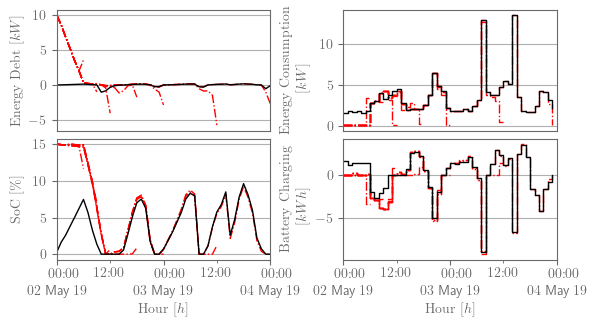

In [15]:
# Set rcParams
export = True
plt.style.use('default') # 'seaborn-v0_8-darkgrid
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.color'] = 'dimgray'
plt.rcParams['ytick.color'] = 'dimgray'
plt.rcParams['axes.edgecolor'] = 'dimgray'
plt.rcParams['axes.labelcolor'] = 'dimgray'
plt.rcParams['lines.linewidth'] = 1

# Create time vector
t = 0
agent = 9
dates = [params2.ctrl.start_date + pd.Timedelta(hours = h) for h in range(num_steps+1)]
dates_ol = [params2.ctrl.start_date + pd.Timedelta(hours = h) for h in range(max(horizon)+1)]

# Create figure
fig, axs = plt.subplots(2, 2, figsize=(12, 4), layout='constrained')

# Plot trajectories
for i, _ in enumerate(horizon):
    axs[0][0].plot(dates_ol, x2_ol[i,t,:,agent*2], color='red', linestyle='-.')
    axs[1][0].plot(dates_ol, x2_ol[i,t,:,agent*2+1], color='red', linestyle='-.')
    axs[0][1].plot(dates_ol[:-1], u2_ol[i,t,:,agent*2], color='red', linestyle='-.', drawstyle='steps-post')
    axs[1][1].plot(dates_ol[:-1], u2_ol[i,t,:,agent*2+1], color='red', linestyle='-.', drawstyle='steps-post')

# Plot approximate overtaking-optimal trajectories
for i in [2]:
    axs[0][0].plot(dates, x_inf[t+i*T:t+i*T+num_steps+1,agent*2], color='black', linestyle='-')
    axs[1][0].plot(dates, x_inf[t+i*T:t+i*T+num_steps+1,agent*2+1], color='black', linestyle='-')
    axs[0][1].plot(dates[:-1], u_inf[t+i*T:t+i*T+num_steps,agent*2], color='black', linestyle='-', drawstyle='steps-post')
    axs[1][1].plot(dates[:-1], u_inf[t+i*T:t+i*T+num_steps,agent*2+1], color='black', linestyle='-', drawstyle='steps-post')

# Add labels
axs[0][0].xaxis.set_visible(False)
axs[0][1].xaxis.set_visible(False)
axs[0][0].set_ylabel(r'\rmfamily{Energy Debt} $[kW]$')
axs[1][0].set_ylabel(r'\rmfamily{SoC} $[\%]$')
axs[0][1].set_ylabel(r'\rmfamily{Energy Consumption}\par$\quad\qquad[kW]$')
axs[1][1].set_ylabel(r'\rmfamily{Battery Charging}\par$\quad\quad[kWh]$')
axs[1][0].set_xlabel(r'\rmfamily{Hour} $[h]$')
axs[1][1].set_xlabel(r'\rmfamily{Hour} $[h]$')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
for ax in axs[1]:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[12]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %y'))
    ax.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))

for i, ax in enumerate(axs.flatten()):
    # Set axis limits
    ax.set_xlim([dates_ol[0], dates_ol[-1]])

    # Set grid
    ax.yaxis.grid(True)
    ax.xaxis.grid(False)

# Align labels
fig.align_labels()

# Export figure
if export:
    fig = adjust_margins(fig, width=5, height=2.5, wspace=1.1)
    fig.savefig(f"figures/figure_turnpike_agent{agent+1}_t0_{t:0.1f}.pdf")

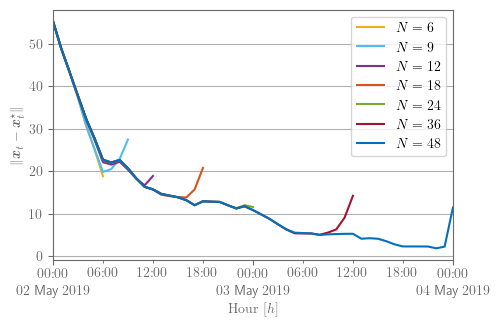

In [16]:
# Set rcParams
export = True
plt.style.use('default') # 'seaborn-v0_8-darkgrid
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.color'] = 'dimgray'
plt.rcParams['ytick.color'] = 'dimgray'
plt.rcParams['axes.edgecolor'] = 'dimgray'
plt.rcParams['axes.labelcolor'] = 'dimgray'
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['text.latex.preamble'] = r"""\usepackage{bm}"""

# Create time vector
dates = [params2.ctrl.start_date + pd.Timedelta(hours = h) for h in range(num_steps+max(horizon)+1)]

# Compute L2-norm
diff_x2_ol = np.full((num_horizon, num_steps, num_steps+max(horizon)+1), np.nan)
for i in range(num_horizon):
    for t in range(num_steps):
        diff_x2_ol[i,t,t:t+horizon[i]+1] = np.linalg.norm(x2_ol[i,t,:horizon[i]+1,:] - x_inf[t+2*T:t+2*T+horizon[i]+1,:], axis=1)  

# Create colormap
colors = lambda i: ["#0072BD", "#A2142F", "#77AC30", "#D95319", "#7E2F8E", "#4DBEEE", "#EDB120"][i % 7]

# Create figure
t = 0
fig, axs = plt.subplots(1, 1, figsize=(12, 4), layout='constrained')

# Plot trajectories without terminal constraints
for i in range(num_horizon):
    axs.plot(dates, diff_x2_ol[i,t,:], color=colors(num_horizon-i-1), linestyle='-', label=f'$N = {horizon[i]}$')

# Add labels
axs.set_ylabel(r"$\|\bm{x}_t - \bm{x}_t^\star\|$")
axs.set_xlabel(r'\rmfamily{Hour} $[h]$')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
axs.xaxis.set_major_locator(mdates.DayLocator(interval=1))
axs.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6,12,18]))
axs.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %Y'))
axs.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))

# Set axis limits
axs.set_xlim([dates[0], dates[max(horizon)]])

# Set grid
axs.yaxis.grid(True)
axs.xaxis.grid(False)
# axs.set_yscale('log')

# Align labels
fig.align_labels()

# Plot legend
axs.legend(loc='best')

# Export figure
if export:
    fig = adjust_margins(fig, width=4, height=2.5, wspace=1.1)
    fig.savefig(f"figures/figure_turnpike_L2norm_t0_{t:0.1f}.pdf")

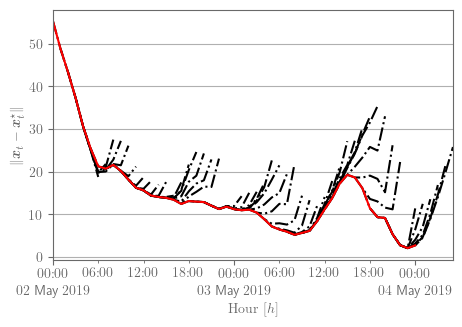

In [17]:
# Set rcParams
export = True
plt.style.use('default') # 'seaborn-v0_8-darkgrid
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.color'] = 'dimgray'
plt.rcParams['ytick.color'] = 'dimgray'
plt.rcParams['axes.edgecolor'] = 'dimgray'
plt.rcParams['axes.labelcolor'] = 'dimgray'
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['text.latex.preamble'] = r"""\usepackage{bm}"""

# Create time vector
idx = 0
dates = [params2.ctrl.start_date + pd.Timedelta(hours = h) for h in range(num_steps+max(horizon)+1)]

# Compute L2-norm
diff_x = np.full((num_horizon, num_steps+1), np.nan)
diff_x_ol = np.full((num_horizon, num_steps, num_steps+max(horizon)+1), np.nan)
for i in range(num_horizon):
    diff_x[i,:] = np.linalg.norm(x2[i,:,:] - x_inf[2*T:2*T+num_steps+1,:], axis=1)
    for t in range(num_steps):
        diff_x_ol[i,t,t:t+horizon[i]+1] = np.linalg.norm(x2_ol[i,t,:horizon[i]+1,:] - x_inf[t+2*T:t+2*T+horizon[i]+1,:], axis=1)    

# Create figure
fig, axs = plt.subplots(1, 1, figsize=(12, 4), layout='constrained')

# Plot open-loop trajectories
for t in range(num_steps):
    axs.plot(dates, diff_x_ol[idx,t,:], color='black', linestyle='-.')

# Plot closed-loop trajectory
axs.plot(dates[:num_steps+1], diff_x[idx,:], color='red', linestyle='-')

# Add labels
axs.set_ylabel(r"$\|\bm{x}_t - \bm{x}_t^\star\|$")
axs.set_xlabel(r'\rmfamily{Hour} $[h]$')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
axs.xaxis.set_major_locator(mdates.DayLocator(interval=1))
axs.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6,12,18]))
axs.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %Y'))
axs.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))

# Set axis limits
axs.set_xlim([dates[0], dates[num_steps+horizon[idx]-1]])

# Set grid
axs.yaxis.grid(True)
axs.xaxis.grid(False)
# axs.set_yscale('log')

# Align labels
fig.align_labels()

# Export figure
if export:
    fig = adjust_margins(fig, width=4, height=2.5, wspace=1.1)
    fig.savefig(f"figures/figure_turnpike_L2norm_N_{horizon[idx]}.pdf")

## Simulate System With Terminal Ingredients

### Compute Periodic Reference Trajectory

In [18]:
# Define period length
T = 96

# Define non-convex cost
gamma_1 = 5 * (1 - 2*np.random.rand(T, 10))

# Load parameters and create periodic system
zeta_max = 40 * np.ones([T,10]); zeta_max[23::24,:] = 1
params_p = DSMPCParams(N=T, T=T, zeta_max=zeta_max, zeta_min=-zeta_max, verbose=False) # gamma_1=gamma_1,
sys_p = LinearSystem(params_p.sys)

# Initialize controller
ctrl_p = CEMPC(sys_p, params_p.ctrl)

# Solve EMPC problem with free initial state
sol_u, sol_x, error_msg, dual_vars_p, stats = ctrl_p.solve(options={'eps_rel': 1E-10, 'eps_abs': 1E-10})
if error_msg != None:
    warnings.warn(error_msg)

# Save trajectory
x_p = sol_x.T
u_p = sol_u.T
dual_vector_p = np.hstack(dual_vars_p[0:ctrl_p.params.N]).T

Convexification problem solved with minimal eigenvalue: 0.09995340898761196
LMIs is positive definite for all times.


### Propagate Lagrange Multipliers

The stage Lagrangian $L_t \in \mathbb{R}$ is defined as
\begin{equation}
    L_{t}(x_t, u_t, p_{t+1}, \eta_t, \mu_t) := \eta_t\, \ell_{t}(x_t, u_t) - p_{t+1}^\top f_{t}(x_t, u_t) + \mu_t^\top g_t(x_t, u_t)
\end{equation}
with the Lagrange multipliers $\eta_t \in \mathbb{R}$, $p_0,\,p_{t+1} \in \mathbb{R}^n$ and $\mu_t \in \mathbb{R}^c$ for all $t \in \mathbb{N}_T$

The dynamics of the Lagrangian multiplier $p_t$ is given by following backward propagation
\begin{align*}
    p_t^\top &= p_{t+1}^\top \frac{\partial f_t}{\partial x}\biggl|_{(x_t^\star, u_t^\star)} -\, \eta_0 \frac{\partial \ell_t}{\partial x}\biggl|_{(x_t^\star, u_t^\star)} -\, \mu_t^\top \frac{\partial g_t}{\partial x}\biggl|_{(x_t^\star, u_t^\star)} \\[20pt]
    p_t^\top  &= p_{t+1}^\top A_t -\, \eta_0\, (x_t^\star){}^\top \boldsymbol{Q}_t -\, \mu_t^\top H_{x,t}
\end{align*}

which we can reformulate to obtain the forward update rule
\begin{align*}
    \Rightarrow p_{t+1}^\top &= \bigl(p_t^\top +\, \eta_0\, (x_t^\star){}^\top \boldsymbol{Q}_t +\, \mu_t^\top H_{x,t} \bigr) A_t^{-1}. \hspace{60pt}
\end{align*}

__Forward Propagation:__

In [19]:
# Allocate Lagrange multipliers p_t
p_t = np.full((T+2, sys_p.n), np.nan)
p_t[1] = dual_vector_p[0]

# Get state multipliers
state_multipliers = dual_vars_p[ctrl_p.params.N:2*ctrl_p.params.N+1]

# Propagate Lagrange multipliers p_t forward
for t in range(1,T):
    b_t = p_t[t] + 1 * ctrl_p.params.stage_cost_grad(x_p[t], u_p[t], t)[0].T + state_multipliers[t].reshape(-1) @ ctrl_p.params.h_x_grad(x_p[t], t)[0].T
    p_t[t+1] = np.linalg.solve(ctrl_p.sys.f_grad(t=t)[0].T, b_t)
b_1 = p_t[-2] + 1 * ctrl_p.params.stage_cost_grad(x_p[T], u_p[0], T)[0].T + state_multipliers[0].reshape(-1) @ ctrl_p.params.h_x_grad(x_p[T], T)[0].T
p_t[-1] = np.linalg.solve(ctrl_p.sys.f_grad(t=t)[0].T, b_1)

# Check periodicity of Lagrange multipliers
matches = np.allclose(p_t[1], p_t[-1], 1E-2)
print(f'Lagrange multipliers are {"periodic" if matches else "not periodic"}.')
print("p_diff = " + np.array2string(p_t[1] - p_t[-1], precision=1, formatter={'float_kind':lambda x: f"{x:.1e}"}))

Lagrange multipliers are periodic.
p_diff = [5.0e-14 4.4e-13 -7.1e-15 2.2e-13 5.0e-14 3.0e-13 -1.6e-13 4.8e-13 7.1e-15 5.6e-13 -1.4e-14 4.4e-13 2.8e-14 3.7e-13 -4.3e-14 1.4e-13 0.0e+00 2.1e-13 -7.1e-15 4.9e-13]


__Backward Propagation:__

In [20]:
# Allocate Lagrange multipliers p_t
p_t = np.full((T+2, sys_p.n), np.nan)
p_t[T+1] = dual_vector_p[0]

# Get state multipliers
state_multipliers = dual_vars_p[ctrl_p.params.N:2*ctrl_p.params.N+1]

# Propagate Lagrange multipliers p_t backwards
p_t[T] = p_t[T+1] @ ctrl_p.sys.f_grad(t=T)[0].T - 1 * ctrl_p.params.stage_cost_grad(x_p[T], u_p[t], T)[0].T - state_multipliers[0].reshape(-1) @ ctrl_p.params.h_x_grad(x_p[t], T)[0].T
for t in range(T-1,0,-1):
    p_t[t] = p_t[t+1] @ ctrl_p.sys.f_grad(t=t)[0].T - 1 * ctrl_p.params.stage_cost_grad(x_p[t], u_p[t], t)[0].T - state_multipliers[t].reshape(-1) @ ctrl_p.params.h_x_grad(x_p[t], t)[0].T

# Check periodicity of Lagrange multipliers
matches = np.allclose(p_t[1], p_t[-1], 5E-2)
print(f'Lagrange multipliers are {"periodic" if matches else "not periodic"}.')
print("p_diff = " + np.array2string(p_t[1] - p_t[-1], precision=1, formatter={'float_kind':lambda x: f"{x:.1e}"}))

Lagrange multipliers are periodic.
p_diff = [-1.4e+00 1.3e-03 9.9e-01 8.7e-04 -1.7e-01 1.1e-03 -2.2e-01 1.1e-03 -2.2e-01 1.1e-03 -5.4e-01 1.2e-03 -1.6e+00 1.5e-03 1.6e+00 7.5e-04 -8.0e-01 1.2e-03 -8.8e-01 1.2e-03]


### Multiplier Plots

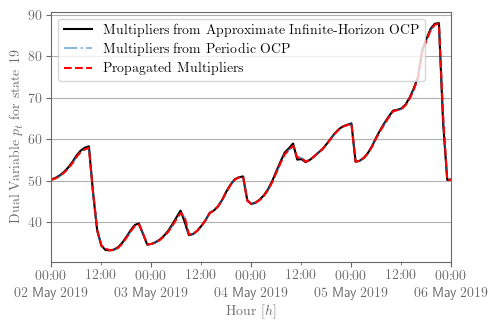

In [21]:
# Set font style
export = True
plt.style.use('default') # 'seaborn-v0_8-darkgrid
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.color'] = 'dimgray'
plt.rcParams['ytick.color'] = 'dimgray'
plt.rcParams['axes.edgecolor'] = 'dimgray'
plt.rcParams['axes.labelcolor'] = 'dimgray'
plt.rcParams['lines.linewidth'] = 1.5

# Create dates vector and get state related dual variables
idx = 19
dates = np.hstack([params_p.ctrl.start_date + pd.Timedelta(hours = h) for h in range(T+1)])
dual_vector_inf = np.hstack(dual_vars_inf[0:ctrl_inf.params.N]).T

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')

# Plot multipliers
for i in [2]:
    ax.plot(dates, dual_vector_inf[i*T:(i+1)*T+1,idx].T, ls='-', color='black', label=r'\rmfamily{Multipliers from Approximate Infinite-Horizon OCP}' if i == 2 else None)
ax.plot(dates[:-1], dual_vector_p[:,idx].T, ls='-.', color='tab:blue', alpha=0.5, label=r'\rmfamily{Multipliers from Periodic OCP}')
ax.plot(dates, p_t[1:,idx].T, ls='--', color='red', label=r'\rmfamily{Propagated Multipliers}')

# Add labels and title
ax.set_xlabel(r'\rmfamily{Hour} $[h]$')
ax.set_ylabel(r'\rmfamily{Dual Variable $p_{t}$ for state ' + str(idx) + r'}')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[12]))
ax.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %Y'))
ax.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))
ax.yaxis.set_major_locator(ticker.MultipleLocator(base=10, offset=0))
ax.tick_params(axis="x", which="minor", pad=ax.xaxis.get_tick_padding())

# Set limits
plt.autoscale(enable=True, axis='x', tight=True)

# Set grid
ax.yaxis.grid(True)
ax.xaxis.grid(False)

# Plot legend
ax.legend(loc='best')

# Export figure
if export:
    fig = adjust_margins(fig, width=4, height=2.5, wspace=1.1)
    fig.savefig(f"figures/figure_dual_variable_{idx}_periodic_sol.pdf")

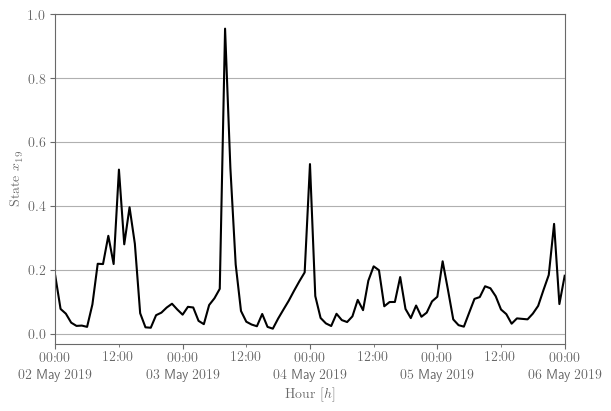

In [61]:
# Set font style
export = False
plt.style.use('default') # 'seaborn-v0_8-darkgrid
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.color'] = 'dimgray'
plt.rcParams['ytick.color'] = 'dimgray'
plt.rcParams['axes.edgecolor'] = 'dimgray'
plt.rcParams['axes.labelcolor'] = 'dimgray'
plt.rcParams['lines.linewidth'] = 1.5

# Create dates vector and get state related dual variables
dates = np.hstack([params_p.ctrl.start_date + pd.Timedelta(hours = h) for h in range(T+1)])

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')

# Plot multipliers
for i in [2]:
    rel_diff_x_p = np.linalg.norm(x_p - x_inf[i*T:(i+1)*T+1,:], axis=1) / np.linalg.norm(x_inf[i*T:(i+1)*T+1,:], axis=1)
    ax.plot(dates, rel_diff_x_p, ls='-', color='black')

# Add labels and title
ax.set_xlabel(r'\rmfamily{Hour} $[h]$')
ax.set_ylabel(r'\rmfamily{State} $x_{' + str(idx) + r'}$')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[12]))
ax.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %Y'))
ax.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))
# ax.tick_params(axis="x", which="minor", pad=ax.xaxis.get_tick_padding())

# Set limits
plt.autoscale(enable=True, axis='x', tight=True)

# Set grid
ax.yaxis.grid(True)
ax.xaxis.grid(False)

# Export figure
if export:
    fig = adjust_margins(fig, width=4, height=2.5, wspace=1.1)
    fig.savefig(f"figures/figure_trajectory_inf_p_L2norm.pdf")

### Solve DSMPC for Varying Initial States

In [62]:
# Initialize controller
paramst = ctrl_p.params
paramst.N = 24
ctrl = EMPC(sys_p, paramst)

# Setup simulation
num_steps = 48
xt_0 = [np.tile(np.array([10/4*i, 15/4*i]), 10) for i in range(5)]
num_traj  = len(x_0)

# Allocate state and input trajectories
xt = np.full((num_traj, num_steps+1, sys.n), np.nan)
ut = np.full((num_traj, num_steps,   sys.m), np.nan)
xt_ol = np.full((num_traj, paramst.N+1, sys.n), np.nan)
ut_ol = np.full((num_traj, paramst.N,   sys.m), np.nan)

# Simulate closed-loop system
for i, xi_0 in enumerate(tqdm(xt_0, desc='Trajectories', leave=False)):
    # Set initial state
    xt[i,0,:] = xi_0

    # Simulate closed-loop system
    for t in tqdm(range(num_steps),desc='     MPC', leave=False):
        # Solve the EMPC problem
        sol_u, sol_x, error_msg, _, _ = ctrl.solve(t=t, x_0=xt[i,t,:], x_T=x_p[t+paramst.N,:])
        if error_msg != None:
            warnings.warn(error_msg)
            break
        
        # Save open-loop trajectory
        if t == 0:
            xt_ol[i,:] = sol_x.T
            ut_ol[i,:] = sol_u.T

        # Propagate dynamics and save input
        ut[i,t,:]   = sol_u[:,0]
        xt[i,t+1,:] = sys.f(sol_x[:,0], sol_u[:,0], t=t).reshape((sys.n,))
        sleep(0.01)

# Clear cell output
clear_output()

### Solve DSMPC for Varying Horizons

In [66]:
# Setup simulation
num_steps = 48
horizont = [24, 36, 48]
num_horizont = len(horizont)

# Allocate state and input trajectories
xt2 = np.full((num_horizont, num_steps+1, sys.n), np.nan)
ut2 = np.full((num_horizont, num_steps,   sys.m), np.nan)
xt2_ol = np.full((num_horizont, num_steps, max(horizont)+1, sys.n), np.nan)
ut2_ol = np.full((num_horizont, num_steps, max(horizont),   sys.m), np.nan)

# Simulate closed-loop system
for i, N in enumerate(tqdm(horizont, desc='Horizons', leave=False)):
    # Load parameters and create system
    paramst.N = N

    # Initialize controller
    ctrl2 = EMPC(ctrl_p.sys, paramst)

    # Set initial state
    xt2[i,0,:] = np.tile(np.array([10, 15]), 10)

    # Simulate closed-loop system
    for t in tqdm(range(num_steps),desc='   MPC', leave=False):
        # Solve the EMPC problem
        sol_u, sol_x, error_msg, _, _ = ctrl2.solve(t=t, x_0=xt2[i,t,:], x_T=x_p[t+N,:])
        if error_msg != None:
            warnings.warn(error_msg)
            break
        
        # Save open-loop trajectory
        xt2_ol[i,t,:N+1,:] = sol_x.T
        ut2_ol[i,t,:N,:]   = sol_u.T

        # Propagate dynamics and save input
        ut2[i,t,:]   = sol_u[:,0]
        xt2[i,t+1,:] = sys2.f(sol_x[:,0], sol_u[:,0], t=t).reshape((sys.n,))
        sleep(0.01)

# Clear cell output
clear_output()

### Compare Cost

In [74]:
# Compute cost with and without terminal constraints
data = []
for i in range(num_traj):
    cost, costt = 0, 0
    for k in range(num_steps):
        cost  += params.ctrl.stage_cost(x[i, k],  u[i, k],  t=k)[0]
        costt += params.ctrl.stage_cost(xt[i, k], ut[i, k], t=k)[0]
    
    # Append the computed costs
    data.append([cost, costt, np.abs(cost/costt-1)])

# Create a pandas DataFrame
columns = pd.MultiIndex.from_tuples([('Cost', 'Without'), ('Cost', 'With'), ('Rel. Diff','[%]')])
cost_df = pd.DataFrame(data, columns=columns, index=pd.Index(range(num_traj), name="Trajectory"))
cost_df

Cost               Rel. Diff
                 Without          With       [%]
Trajectory                                      
0           30299.235613  30538.646827  0.007840
1           27918.862319  28156.698400  0.008447
2           27541.958577  27778.072686  0.008500
3           30191.333523           NaN       NaN
4           38628.306038           NaN       NaN

### Asymptotic Convergence

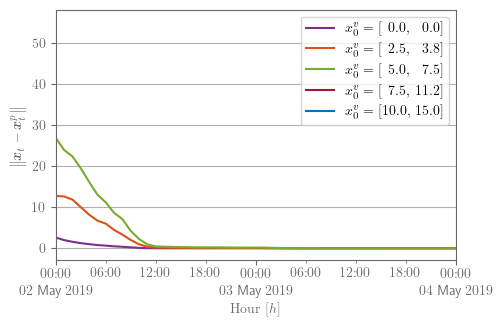

In [79]:
# Set rcParams
export = True
plt.style.use('default') # 'seaborn-v0_8-darkgrid
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.color'] = 'dimgray'
plt.rcParams['ytick.color'] = 'dimgray'
plt.rcParams['axes.edgecolor'] = 'dimgray'
plt.rcParams['axes.labelcolor'] = 'dimgray'
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['text.latex.preamble'] = r"""\usepackage{bm}"""

# Create time vector
dates = [params.ctrl.start_date + pd.Timedelta(hours = h) for h in range(num_steps+1)]

# Compute L2-norm
diff_xt = np.full((num_traj, num_steps+1), np.nan)
for i in range(num_traj):
    diff_xt[i,:] = np.linalg.norm(xt[i] - x_p[:num_steps+1], axis=1)
    # diff_xt[i,:] = np.linalg.norm(xt[i] - x_inf[2*T:2*T+num_steps+1,:], axis=1)

# Create colormap
colors = lambda i: ["#0072BD", "#A2142F", "#77AC30", "#D95319", "#7E2F8E", "#4DBEEE", "#EDB120"][i % 7]

# Create figure
fig, axs = plt.subplots(1, 1, figsize=(12, 4), layout='constrained')

# Plot trajectories
for i in range(num_traj):
    label_name = np.array2string(xt_0[i][0:2], separator=',\,', formatter={'float_kind':lambda x: f"{x:4.1f}".replace(' ', r'\phantom{0}')})
    axs.plot(dates, diff_xt[i,:], color=colors(num_traj-i-1), linestyle='-', label=f'$x_0^v = {label_name}$')

# Add labels
axs.set_ylabel(r"$\bigl\|\bm{x}_t - \bm{x}_t^p\bigr\|$")
axs.set_xlabel(r'\rmfamily{Hour} $[h]$')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
axs.xaxis.set_major_locator(mdates.DayLocator(interval=1))
axs.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6,12,18]))
axs.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %Y'))
axs.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))

# Set axis limits
axs.set_xlim([dates[0], dates[-1]])

# Set grid
axs.yaxis.grid(True)
axs.xaxis.grid(False)
# axs.set_yscale('log')

# Align labels
fig.align_labels()

# Plot legend
axs.legend(loc='best')

# Export figure
if export:
    fig = adjust_margins(fig, width=4, height=2.5, wspace=1.1)
    fig.savefig(f"figures/figure_asymptotic_convergence_L2norm_periodic.pdf")

### Feasible Region

In [449]:
# Allocate feasible set
horizon_f = range(1,49)
num_horizon_f = len(horizon_f)
f_set_p = np.full((num_horizont, num_steps+1, sys.n), np.nan)

# Sample feasible set
feasible_set = [[],[],[]]
for i, N in enumerate(tqdm(horizon_f, desc='Horizons', leave=False)):
    # Define decision variables
    r = cp.Variable(nonneg=True)
    x = cp.Variable((sys.n, N + 1))
    u = cp.Variable((sys.m, N))
    x_r = cp.Parameter((sys.n))

    # Define dynamics constraints
    dynamics_constraints = []
    for k in range(N):
        dynamics_constraints += [x[:,k+1].reshape((sys_p.n,1)) == sys_p.f(x[:,k], u[:,k], t=k)]

    # Define state and input constraints
    input_constraints = []
    state_constraints = [x[:,0] == r*x_r]
    for k in range(N):
        input_constraints += [paramst.h_u(u[:,k], t=k) <= 0]
        state_constraints += [paramst.h_x(x[:,k], t=k) <= 0]
    state_constraints += [x[:,N] == x_p[N,:]]

    # Setup solver
    prob = cp.Problem(cp.Maximize(r), dynamics_constraints + state_constraints + input_constraints)

    # Sample state space (in polar coordinates)
    x_0 = [[],[]]
    angles = 2*np.pi * np.arange(31) / 30
    for phi in tqdm(angles,desc='    OCP', leave=False):
        # Set parameter
        x_r.value = np.tile([np.cos(phi), np.sin(phi)], params_p.M)

        # Solve feasibility problem
        prob.solve()
        if prob.status == cp.OPTIMAL:
            r_val = r.value
            x_0[0].append(r_val*np.cos(phi))
            x_0[1].append(r_val*np.sin(phi))
        else:
            x_0[0].append(None)
            x_0[1].append(None)
            warnings.warn(f'Feasibility problem for N = {N} and phi = {phi:.2f} was infeasible.')
        sleep(0.01)
    
    # Stack vectors
    x_0[0] = np.stack([x_0[0]])
    x_0[1] = np.stack([x_0[1]])

    # Save feasible set (with 8 steps in N)
    feasible_set[0].append(np.tile(x_0[0], (8,1)))
    feasible_set[1].append(np.tile(x_0[1], (8,1)))
    feasible_set[2].append(np.tile(np.linspace(N-1,N, num=8).reshape(-1,1), (1, x_0[0].shape[1])))

# Stack vectors
feasible_set[0] = np.vstack(feasible_set[0])
feasible_set[1] = np.vstack(feasible_set[1])
feasible_set[2] = np.vstack(feasible_set[2])

# Clear cell output
clear_output()

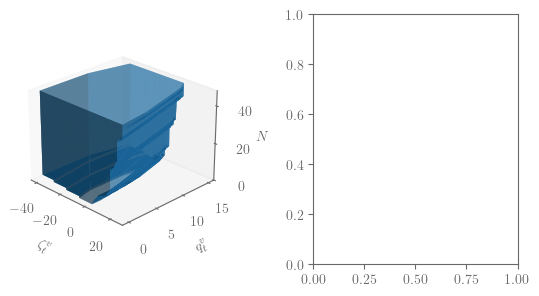

In [480]:
from matplotlib.colors import LightSource

# Set rcParams
export = True
plt.style.use('default') # 'seaborn-v0_8-darkgrid
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.color'] = 'dimgray'
plt.rcParams['ytick.color'] = 'dimgray'
plt.rcParams['axes.edgecolor'] = 'dimgray'
plt.rcParams['axes.labelcolor'] = 'dimgray'
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['text.latex.preamble'] = r"""\usepackage{bm}"""

# Create figure
axs = [[],[]]
fig = plt.figure(figsize=(12, 4), layout='constrained')
axs[0] = fig.add_subplot(1, 2, 1, projection='3d')
axs[1] = fig.add_subplot(1, 2, 2)

# Plot the surface
axs[0].plot_surface(*feasible_set, rstride=1, cstride=1, linewidth=0, antialiased=True, alpha=1, shade=True, lightsource=LightSource(azdeg=0, altdeg=-45))

# Add labels
axs[0].set_zlabel(r"$N$")
axs[0].set_ylabel(r"$q_t^v$")
axs[0].set_xlabel(r"$\zeta_t^v$")
axs[0].zaxis.labelpad=-2

# Set axis limits
axs[0].set_zlim(0, N)

# Update grid
axs[0].xaxis._axinfo['grid'].update(linewidth=0)
axs[0].yaxis._axinfo['grid'].update(linewidth=0)
axs[0].zaxis._axinfo['grid'].update(linewidth=0) # color='dimgray', linestyle='-'

# Set ticks
# ax.set(xticklabels=[], yticklabels=[],  zticklabels=[])

# Set view angle (elevation and azimuth)
axs[0].view_init(elev=25, azim=315)

# Export figure
if export:
    fig = adjust_margins(fig, width=5, height=2.5, wspace=1.3)
    fig.savefig(f"figures/figure_feasible_region_cempc.pdf")

In [479]:
import plotly.graph_objects as go

fig = go.Figure(
    data=[go.Surface(z=feasible_set[2], x=feasible_set[0], y=feasible_set[1], colorscale=[[0,'rgb(0,0,255)'], [1,'rgb(0,0,255)']], opacity=0.5,
                     contours={"x": {"show": False}, "y": {"show": False},  "z": {"show": True, "color": "blue", "width": 10, "size": 1}
    })])

# Hide colorbar
fig.update_traces(showscale=False)

fig.update_layout(
    title=None, 
    autosize=False,
    width=1000, 
    height=500,
    margin=dict(l=65, r=50, b=65, t=90), 
    scene_aspectmode='cube'
)